# Cluster Analysis: Customer Segmentation from Purchasing Behavior

This Notebook applies cluster analysis to customer behavior data and discovers groups of customers with similar characteristics.

The objective is to understand how customers differ in terms of income, purchase frequency, average order value, online usage, discount usage, and recency.

# クラスター分析：購買行動による顧客セグメンテーション

このNotebookでは、顧客行動データにクラスター分析を適用し、似た特徴を持つ顧客グループを発見します。

年収、購入頻度、平均購入金額、オンライン利用率、割引利用率、最終購入からの日数などを用いて、顧客の違いを理解することが目的です。

## 1. Learning Objectives / 学習目標

By completing this Notebook, you will learn:

- What cluster analysis is
- The difference between supervised and unsupervised learning
- Why feature standardization is necessary
- How hierarchical clustering and dendrograms work
- How to use the elbow method and silhouette score
- How to perform K-means clustering
- How to interpret and name clusters

このNotebookでは、次の内容を学びます。

- クラスター分析とは何か
- 教師あり学習と教師なし学習の違い
- 標準化が必要な理由
- 階層型クラスタリングとデンドログラム
- エルボー法とシルエットスコア
- K-means法の実行方法
- クラスターの解釈と命名方法

## 2. Use Case / ユースケース

An e-commerce company stores customer purchase and usage data. However, it does not yet know what types of customers exist in its customer base.

The company wants to discover natural customer groups and use the results for marketing strategy, customer retention, and campaign design.

あるECサイトでは、顧客の購買履歴や利用状況を蓄積しています。しかし、顧客の中にどのようなタイプが存在するかは明確になっていません。

そこで、顧客の特徴から自然なグループを発見し、マーケティング施策、顧客維持、キャンペーン設計に活用します。

## 3. Import Libraries / ライブラリの読み込み

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)

## 4. Load the Dataset / データの読み込み

The code below searches for the dataset from either the Notebook directory or the repository root, making the Notebook easier to run in different environments.

以下のコードでは、Notebookディレクトリとリポジトリルートの両方からデータファイルを探索します。環境が変わっても実行しやすい構成です。

In [2]:
candidate_paths = [
    Path("../data/customer_behavior.csv"),
    Path("04_cluster_analysis/data/customer_behavior.csv"),
    Path("data/customer_behavior.csv"),
]

data_path = next((path for path in candidate_paths if path.exists()), None)

if data_path is None:
    raise FileNotFoundError(
        "customer_behavior.csv was not found. "
        "Run this Notebook from the notebooks directory or repository root."
    )

df = pd.read_csv(data_path)
df.head()

,customer_id,age,annual_income,purchase_frequency,average_order_value,online_purchase_ratio,discount_usage_rate,days_since_last_purchase
0,C001,29,50000,6.0,106.92,99.3,40.6,15
1,C002,38,51100,8.1,77.20,92.1,10.0,18
2,C003,31,100500,11.9,122.54,69.7,17.6,10
3,C004,26,68800,8.3,99.03,89.6,24.5,17
4,C005,51,83700,9.6,168.09,49.4,30.6,1


## 5. Understand the Dataset / データの理解

Before clustering, confirm the number of records, data types, missing values, distributions, and summary statistics.

クラスター分析の前に、データ件数、データ型、欠損値、分布、基本統計量を確認します。

In [3]:
print(f"Rows: {df.shape[0]}")
print(f"Columns: {df.shape[1]}")
df.info()

Rows: 120
Columns: 8
<class 'pandas.DataFrame'>
RangeIndex: 120 entries, 0 to 119
Data columns (total 8 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   customer_id               120 non-null    str    
 1   age                       120 non-null    int64  
 2   annual_income             120 non-null    int64  
 3   purchase_frequency        120 non-null    float64
 4   average_order_value       120 non-null    float64
 5   online_purchase_ratio     120 non-null    float64
 6   discount_usage_rate       120 non-null    float64
 7   days_since_last_purchase  120 non-null    int64  
dtypes: float64(4), int64(3), str(1)
memory usage: 7.6 KB


In [4]:
df.isna().sum()

customer_id                 0
age                         0
annual_income               0
purchase_frequency          0
average_order_value         0
online_purchase_ratio       0
discount_usage_rate         0
days_since_last_purchase    0
dtype: int64

In [5]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
age,120.0,41.716667,12.189804,18.00,31.0000,42.000,50.000,75.00
annual_income,120.0,64230.833333,21381.932198,25100.00,48675.0000,58650.000,80425.000,126500.00
purchase_frequency,120.0,6.271667,3.594935,0.30,2.6750,6.650,9.250,12.20
average_order_value,120.0,100.174000,43.032159,23.53,68.6625,93.395,122.980,213.03
online_purchase_ratio,120.0,57.691667,23.418805,5.00,42.0000,54.600,78.750,99.30
discount_usage_rate,120.0,42.685833,24.738227,4.60,20.9000,39.050,63.275,97.00
days_since_last_purchase,120.0,32.350000,35.009879,1.00,10.0000,16.000,37.250,142.00


### Distribution of Variables / 各変数の分布

The variables use different units and scales. This is important because distance-based algorithms are strongly affected by scale.

各変数は異なる単位とスケールを持っています。距離を用いるアルゴリズムはスケールの影響を強く受けるため、この違いは重要です。

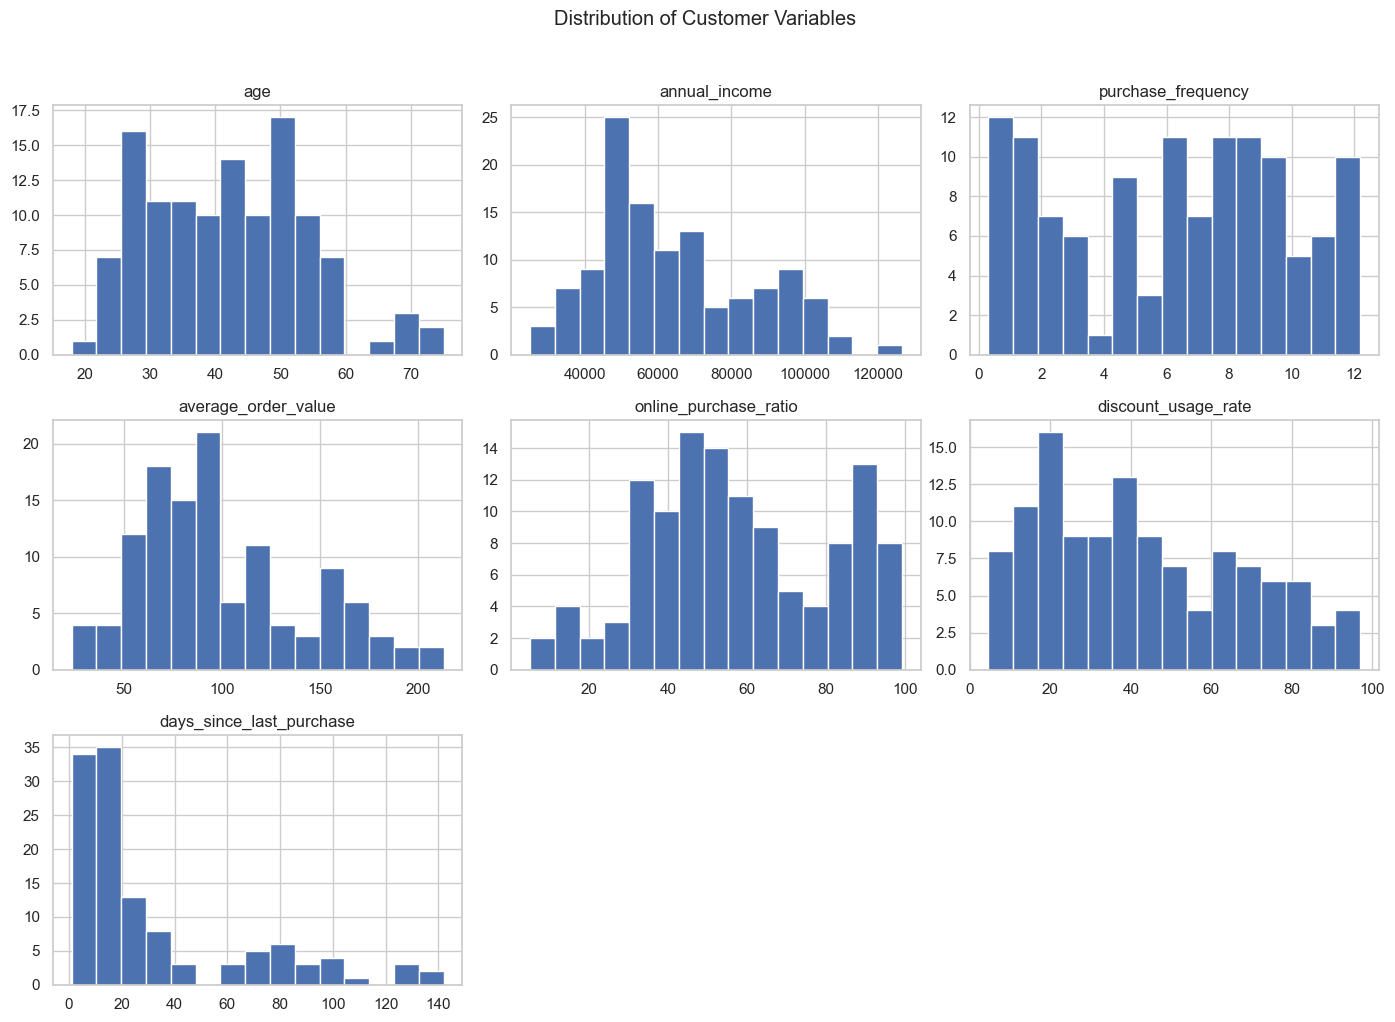

In [6]:
numeric_columns = [
    "age",
    "annual_income",
    "purchase_frequency",
    "average_order_value",
    "online_purchase_ratio",
    "discount_usage_rate",
    "days_since_last_purchase",
]

df[numeric_columns].hist(figsize=(14, 10), bins=15)
plt.suptitle("Distribution of Customer Variables", y=1.02)
plt.tight_layout()
plt.show()

### Correlation Matrix / 相関行列

The correlation matrix helps us understand linear relationships among variables before clustering.

相関行列を確認し、クラスタリング前に変数同士の線形関係を把握します。

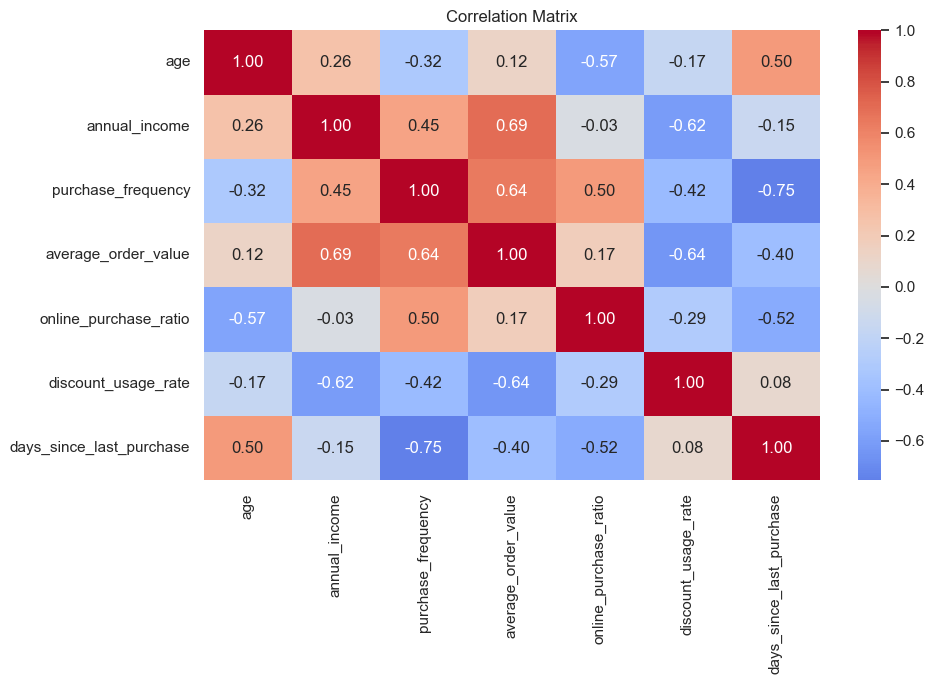

In [7]:
plt.figure(figsize=(10, 7))
sns.heatmap(
    df[numeric_columns].corr(),
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
)
plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()

## 6. Feature Selection / 分析対象変数の選択

`customer_id` is an identifier and does not represent customer behavior, so it is excluded from clustering.

`customer_id`は識別用の項目であり、顧客の行動特性ではないため、クラスタリング対象から除外します。

In [8]:
features = [
    "age",
    "annual_income",
    "purchase_frequency",
    "average_order_value",
    "online_purchase_ratio",
    "discount_usage_rate",
    "days_since_last_purchase",
]

X = df[features].copy()
X.head()

,age,annual_income,purchase_frequency,average_order_value,online_purchase_ratio,discount_usage_rate,days_since_last_purchase
0,29,50000,6.0,106.92,99.3,40.6,15
1,38,51100,8.1,77.20,92.1,10.0,18
2,31,100500,11.9,122.54,69.7,17.6,10
3,26,68800,8.3,99.03,89.6,24.5,17
4,51,83700,9.6,168.09,49.4,30.6,1


## 7. Standardization / 標準化

Annual income may be measured in tens of thousands of dollars, while purchase frequency may be less than 20. Without standardization, variables with large numerical scales dominate the distance calculation.

Standardization transforms each variable so that it has approximately mean 0 and standard deviation 1.

年収は数万ドル単位ですが、購入頻度は20未満の値です。標準化を行わない場合、数値スケールの大きい変数が距離計算を支配してしまいます。

標準化によって、各変数を平均0、標準偏差1程度の共通スケールへ変換します。

In [9]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_scaled_df = pd.DataFrame(X_scaled, columns=features)
X_scaled_df.describe().round(2)

,age,annual_income,purchase_frequency,average_order_value,online_purchase_ratio,discount_usage_rate,days_since_last_purchase
count,120.00,120.00,120.00,120.00,120.00,120.00,120.00
mean,-0.00,-0.00,0.00,-0.00,-0.00,-0.00,-0.00
std,1.00,1.00,1.00,1.00,1.00,1.00,1.00
min,-1.95,-1.84,-1.67,-1.79,-2.26,-1.55,-0.90
25%,-0.88,-0.73,-1.00,-0.74,-0.67,-0.88,-0.64
50%,0.02,-0.26,0.11,-0.16,-0.13,-0.15,-0.47
75%,0.68,0.76,0.83,0.53,0.90,0.84,0.14
max,2.74,2.92,1.66,2.63,1.78,2.20,3.15


## 8. Hierarchical Clustering / 階層型クラスタリング

Hierarchical clustering gradually combines similar observations. A dendrogram visualizes this merging process.

The dendrogram is used as an exploratory tool to estimate a reasonable number of clusters.

階層型クラスタリングでは、似ている対象を段階的にまとめます。デンドログラムは、その結合過程を可視化したものです。

ここでは、適切なクラスター数を考えるための探索的な手段として利用します。

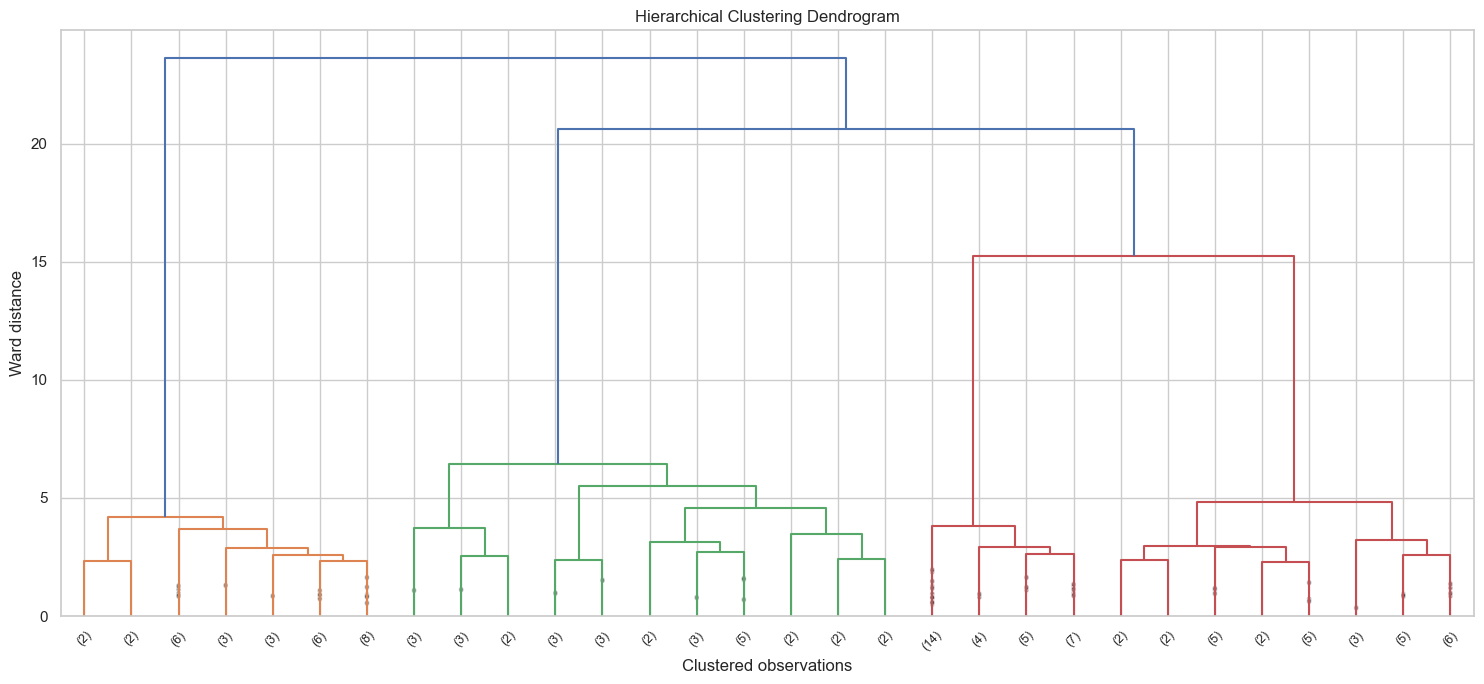

In [10]:
linked = linkage(X_scaled, method="ward")

plt.figure(figsize=(15, 7))
dendrogram(
    linked,
    truncate_mode="lastp",
    p=30,
    leaf_rotation=45,
    leaf_font_size=9,
    show_contracted=True,
)
plt.title("Hierarchical Clustering Dendrogram")
plt.xlabel("Clustered observations")
plt.ylabel("Ward distance")
plt.tight_layout()
plt.show()

## 9. Determine the Number of Clusters / クラスター数の検討

There is no universally correct number of clusters. We compare two common indicators:

- **Elbow method**: looks for the point where the decrease in within-cluster variation becomes smaller.
- **Silhouette score**: measures how well each observation fits within its cluster compared with other clusters.

唯一絶対のクラスター数が存在するとは限りません。ここでは、代表的な2つの指標を比較します。

- **エルボー法**：クラスター内変動の減少が緩やかになる折れ曲がりを探す。
- **シルエットスコア**：各データが自クラスターにどの程度適合し、他クラスターから分離されているかを測る。

In [11]:
k_values = range(2, 9)
inertias = []
silhouette_scores = []

for k in k_values:
    model = KMeans(n_clusters=k, random_state=42, n_init=20)
    labels = model.fit_predict(X_scaled)
    inertias.append(model.inertia_)
    silhouette_scores.append(silhouette_score(X_scaled, labels))

evaluation_df = pd.DataFrame(
    {
        "k": list(k_values),
        "inertia": inertias,
        "silhouette_score": silhouette_scores,
    }
)

evaluation_df

,k,inertia,silhouette_score
0,2,515.164166,0.354022
1,3,339.356887,0.398142
2,4,222.783056,0.430825
3,5,204.610710,0.389167
4,6,192.464693,0.388766
5,7,184.460362,0.238942
6,8,171.805773,0.333966


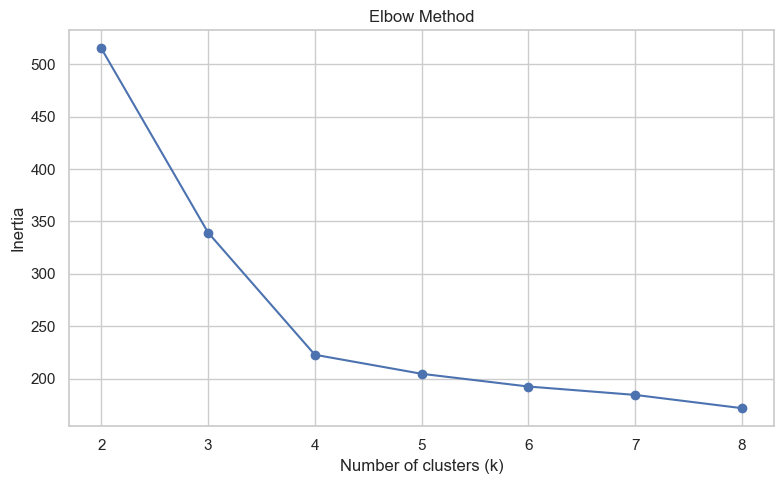

In [12]:
plt.figure(figsize=(8, 5))
plt.plot(evaluation_df["k"], evaluation_df["inertia"], marker="o")
plt.xlabel("Number of clusters (k)")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.xticks(list(k_values))
plt.tight_layout()
plt.show()

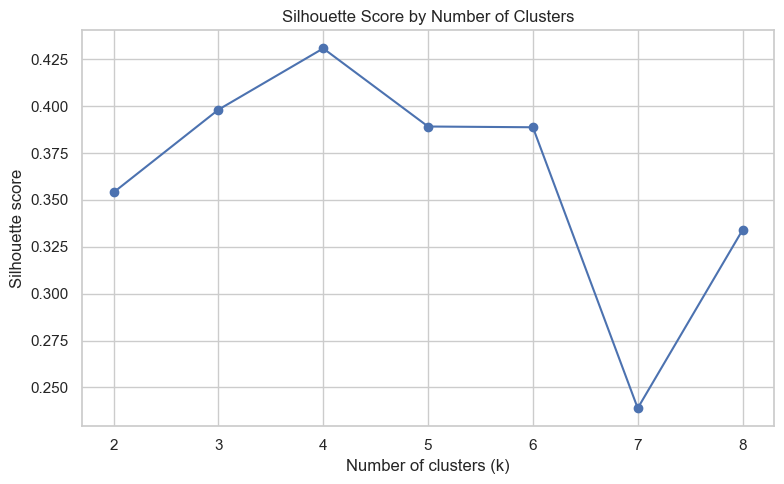

In [13]:
plt.figure(figsize=(8, 5))
plt.plot(
    evaluation_df["k"],
    evaluation_df["silhouette_score"],
    marker="o",
)
plt.xlabel("Number of clusters (k)")
plt.ylabel("Silhouette score")
plt.title("Silhouette Score by Number of Clusters")
plt.xticks(list(k_values))
plt.tight_layout()
plt.show()

### Selected Number of Clusters / 採用するクラスター数

For this educational dataset, we use four clusters based on the dendrogram, the elbow pattern, and the silhouette scores.

In real analysis, the final choice should also consider business usefulness, interpretability, sample size, and stability.

この学習用データでは、デンドログラム、エルボー法、シルエットスコアを総合し、4クラスターを採用します。

実際の分析では、ビジネス上の有用性、解釈可能性、サンプルサイズ、結果の安定性も考慮する必要があります。

## 10. K-means Clustering / K-means法

K-means assigns observations to the nearest cluster center and repeatedly updates the centers until the assignments stabilize.

K-means法では、各データを最も近いクラスター中心へ割り当て、割り当てが安定するまでクラスター中心を更新します。

In [14]:
n_clusters = 4

kmeans = KMeans(
    n_clusters=n_clusters,
    random_state=42,
    n_init=20,
)

df["cluster"] = kmeans.fit_predict(X_scaled)
df[["customer_id", "cluster"]].head(10)

,customer_id,cluster
0,C001,2
1,C002,2
2,C003,1
3,C004,2
4,C005,1
5,C006,3
6,C007,2
7,C008,1
8,C009,2
9,C010,0


## 11. Cluster Size / クラスターごとの件数

Check whether any cluster contains too few observations.

各クラスターのデータ件数を確認し、極端に小さなクラスターがないかを確認します。

In [15]:
cluster_counts = (
    df["cluster"]
    .value_counts()
    .sort_index()
    .rename_axis("cluster")
    .reset_index(name="customer_count")
)

cluster_counts

,cluster,customer_count
0,0,29
1,1,30
2,2,31
3,3,30


## 12. Cluster Profiles / クラスターの特徴

Cluster numbers such as 0, 1, 2, and 3 have no inherent meaning. We calculate the average values for each cluster and interpret their characteristics.

0、1、2、3といったクラスター番号自体には意味がありません。クラスターごとの平均値を比較し、特徴を解釈します。

In [16]:
cluster_profile = (
    df.groupby("cluster")[features]
    .mean()
    .round(2)
)

cluster_profile

,age,annual_income,purchase_frequency,average_order_value,online_purchase_ratio,discount_usage_rate,days_since_last_purchase
cluster,,,,,,,
0,53.48,60331.03,1.47,74.58,36.32,41.76,88.41
1,47.17,93896.67,10.30,161.70,57.84,17.30,9.20
2,28.48,53570.97,7.87,96.88,88.12,35.86,12.29
3,38.57,49350.00,5.23,66.80,46.76,76.02,22.03


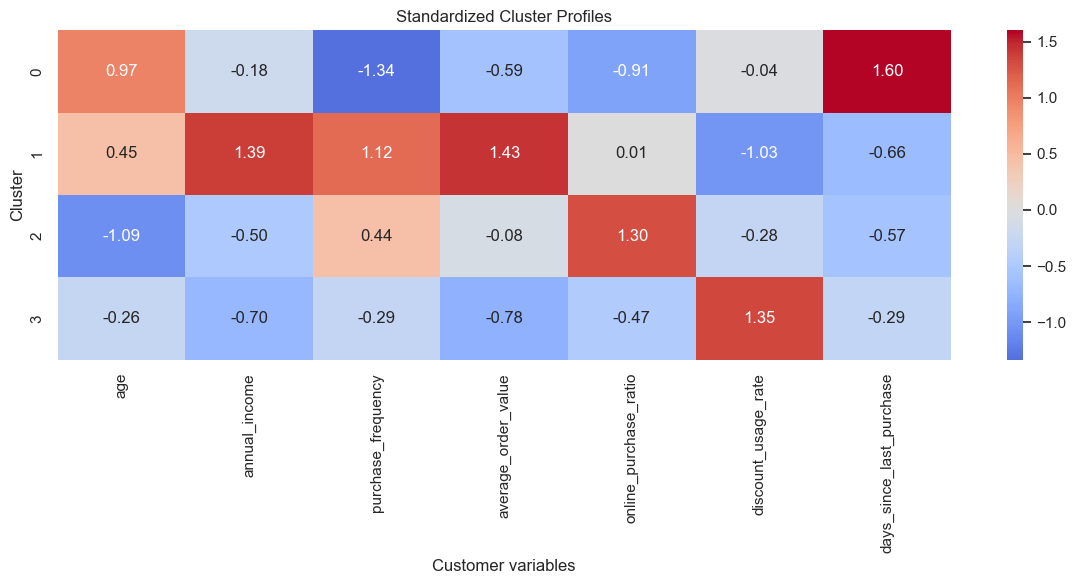

In [17]:
overall_mean = df[features].mean()
cluster_profile_standardized = (
    cluster_profile - overall_mean
) / df[features].std()

plt.figure(figsize=(12, 6))
sns.heatmap(
    cluster_profile_standardized,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
)
plt.title("Standardized Cluster Profiles")
plt.xlabel("Customer variables")
plt.ylabel("Cluster")
plt.tight_layout()
plt.show()

## 13. Visualize Clusters with PCA / PCAによるクラスターの可視化

The original dataset has seven dimensions and cannot be shown directly on a two-dimensional chart. PCA is used only for visualization, reducing the standardized variables to two components.

元のデータは7次元であり、そのまま二次元グラフへ表示できません。ここでは可視化のためだけにPCAを使い、標準化した変数を2つの主成分へ圧縮します。

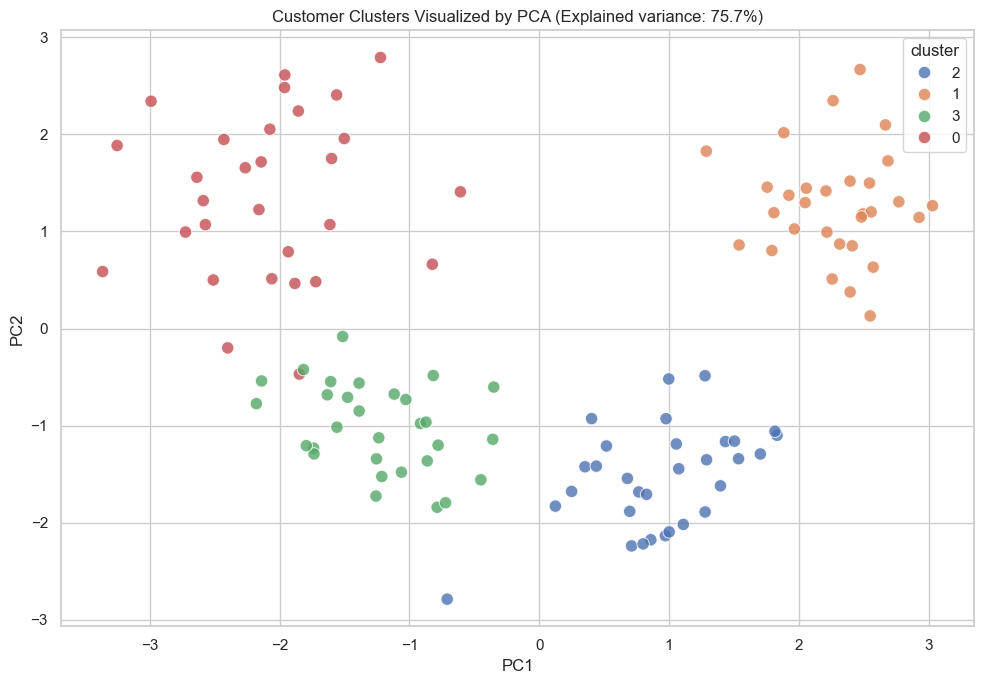

In [18]:
pca = PCA(n_components=2)
components = pca.fit_transform(X_scaled)

plot_df = pd.DataFrame(
    {
        "PC1": components[:, 0],
        "PC2": components[:, 1],
        "cluster": df["cluster"].astype(str),
    }
)

plt.figure(figsize=(10, 7))
sns.scatterplot(
    data=plot_df,
    x="PC1",
    y="PC2",
    hue="cluster",
    s=80,
    alpha=0.8,
)
plt.title(
    "Customer Clusters Visualized by PCA "
    f"(Explained variance: {pca.explained_variance_ratio_.sum():.1%})"
)
plt.tight_layout()
plt.show()

## 14. Name the Clusters / クラスターの命名

The algorithm returns only numeric labels. Analysts must interpret the profile of each cluster and assign meaningful names.

The following code creates names automatically from the relative cluster profiles. These names are analytical interpretations rather than objective facts.

アルゴリズムが返すのは数値ラベルだけです。分析者が各クラスターの特徴を解釈し、意味のある名前を付ける必要があります。

以下では、クラスターの相対的な特徴をもとに名前を割り当てます。これらの名称は客観的事実ではなく、分析上の解釈です。

In [19]:
profile = cluster_profile.copy()

premium_cluster = (
    profile["annual_income"].rank(ascending=False)
    + profile["purchase_frequency"].rank(ascending=False)
    + profile["average_order_value"].rank(ascending=False)
).idxmin()

dormant_cluster = (
    profile["days_since_last_purchase"].rank(ascending=False)
    + profile["purchase_frequency"].rank(ascending=True)
).idxmin()

remaining = [
    cluster
    for cluster in profile.index
    if cluster not in {premium_cluster, dormant_cluster}
]

online_cluster = profile.loc[remaining, "online_purchase_ratio"].idxmax()
discount_cluster = next(
    cluster for cluster in remaining if cluster != online_cluster
)

cluster_name_map = {
    premium_cluster: "Premium Loyal Customers",
    online_cluster: "Digital-First Customers",
    discount_cluster: "Discount-Oriented Customers",
    dormant_cluster: "Low-Engagement Customers",
}

df["cluster_name"] = df["cluster"].map(cluster_name_map)

cluster_name_map

{np.int32(1): 'Premium Loyal Customers',
 np.int32(2): 'Digital-First Customers',
 3: 'Discount-Oriented Customers',
 np.int32(0): 'Low-Engagement Customers'}

In [20]:
named_cluster_profile = (
    df.groupby("cluster_name")[features]
    .mean()
    .round(2)
)

named_cluster_profile

,age,annual_income,purchase_frequency,average_order_value,online_purchase_ratio,discount_usage_rate,days_since_last_purchase
cluster_name,,,,,,,
Digital-First Customers,28.48,53570.97,7.87,96.88,88.12,35.86,12.29
Discount-Oriented Customers,38.57,49350.00,5.23,66.80,46.76,76.02,22.03
Low-Engagement Customers,53.48,60331.03,1.47,74.58,36.32,41.76,88.41
Premium Loyal Customers,47.17,93896.67,10.30,161.70,57.84,17.30,9.20


## 15. Example Marketing Actions / マーケティング施策の例

Possible actions may include:

- **Premium Loyal Customers**: loyalty programs and exclusive offers
- **Digital-First Customers**: app campaigns and personalized online recommendations
- **Discount-Oriented Customers**: coupons and price-sensitive promotions
- **Low-Engagement Customers**: reactivation campaigns and reminder messages

施策例として、次のようなものが考えられます。

- **Premium Loyal Customers**：ロイヤルティプログラムや限定特典
- **Digital-First Customers**：アプリ施策やオンラインでの個別推薦
- **Discount-Oriented Customers**：クーポンや価格訴求型キャンペーン
- **Low-Engagement Customers**：再活性化キャンペーンやリマインド

## 16. Cluster Analysis and Discriminant Analysis / クラスター分析と判別分析

| Cluster Analysis | Discriminant Analysis |
|---|---|
| Unsupervised learning | Supervised learning |
| No known class label | Known class label |
| Discovers groups | Predicts group membership |
| クラスター分析 | 判別分析 |
| 教師なし学習 | 教師あり学習 |
| 正解ラベルなし | 正解ラベルあり |
| グループを発見する | 所属グループを予測する |

The cluster labels discovered here can later be used as target labels in the discriminant analysis content.

今回発見したクラスターを、次章の判別分析における目的変数として利用できます。

## 17. Limitations / 分析上の限界

Important limitations include:

- Results depend on selected variables.
- Results depend on standardization and distance definitions.
- K-means requires the number of clusters to be specified.
- Different random seeds or samples may produce different assignments.
- K-means works best with roughly spherical clusters of similar size.
- Cluster names are subjective interpretations.
- This dataset is simulated for educational purposes.

主な注意点は次のとおりです。

- 選択した変数によって結果が変わる。
- 標準化や距離の定義によって結果が変わる。
- K-means法ではクラスター数を事前に指定する必要がある。
- 乱数やサンプルが変わると所属結果も変化する可能性がある。
- K-means法は、同程度の大きさを持つ球状のクラスターに適しやすい。
- クラスター名は分析者による主観的な解釈である。
- 今回のデータは学習用のシミュレーションデータである。

## 18. Conclusion / まとめ

This Notebook used customer behavior variables to discover four customer groups.

The main analytical workflow was:

1. Explore the data
2. Select behavioral variables
3. Standardize the variables
4. Explore cluster structure with hierarchical clustering
5. Compare candidate values of k
6. Apply K-means
7. Interpret and name the clusters

In the next discriminant analysis content, these discovered groups can be treated as known labels for classifying new customers.

このNotebookでは、顧客行動に関する変数を使い、4つの顧客グループを発見しました。

分析の主な流れは次のとおりです。

1. データを確認する
2. 顧客行動を表す変数を選択する
3. 変数を標準化する
4. 階層型クラスタリングで構造を探索する
5. 候補となるクラスター数を比較する
6. K-means法を実行する
7. クラスターを解釈して命名する

次章の判別分析では、ここで発見したグループを既知のラベルとして扱い、新しい顧客の所属を予測できます。